In [ ]:
# JupyterLite needs openpyxl to read Excel files
%pip install -q openpyxl

In [1]:
import pandas as pd

admissions = pd.read_excel('Time_series_data_5_14.xlsx',skiprows = 13, skipfooter =  3)
admissions.head()

,Unnamed: 0,Year,Period,Beginning of Period,Elective G&A Ordinary Admissions (FFCEs),Elective G&A Daycase Admissions (FFCEs),Elective G&A Total Admissions (FFCEs),Elective G&A Planned Ordinary Admissions (FFCEs),Elective G&A Planned Daycase Admissions (FFCEs),Elective G&A Planned Total Admissions (FFCEs),Elective G&A Admissions (FFCEs) -NHS Treatment Centres (TCs),Total Non-elective G&A Admissions (FFCEs),GP Referrals Made (All specialties),GP Referrals Seen (All specialties),GP Referrals Made (G&A),GP Referrals Seen (G&A),Other Referrals Made (G&A),All 1st Outpatient Attendances (G&A)
0,NaN,2008-09,APRIL,2008-04-01,141966,421825,563791,24225,122080.0,146305.0,14335.0,408413.0,914131.0,762501.0,866763.0,711755.0,459669.0,1189155.0
1,NaN,2008-09,MAY,2008-05-01,138813,393100,531913,22968,118359.0,141327.0,15691.0,419542.0,858883.0,698646.0,820730.0,657553.0,441589.0,1105267.0
2,NaN,2008-09,JUNE,2008-06-01,139990,406636,546626,21983,118809.0,140792.0,13583.0,408705.0,886572.0,755628.0,845108.0,713978.0,461013.0,1187592.0
3,NaN,2008-09,JULY,2008-07-01,149480,437984,587464,24208,127610.0,151818.0,16778.0,424751.0,944448.0,793814.0,901783.0,753847.0,483791.0,1247964.0
4,NaN,2008-09,AUGUST,2008-08-01,133957,378081,512038,22179,111894.0,134073.0,15041.0,404388.0,816623.0,671458.0,777762.0,629963.0,413372.0,1057369.0


In [2]:
elective_surgeries = admissions['Elective G&A Total Admissions (FFCEs)']
elective_surgeries.index = admissions['Beginning of Period']

In [3]:
elective_surgeries = elective_surgeries.asfreq('MS')

<AxesSubplot: xlabel='Beginning of Period'>

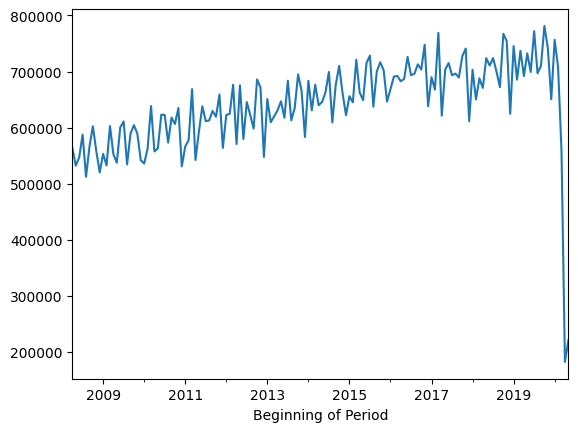

In [4]:
import matplotlib.pyplot as plt
elective_surgeries.plot()

<AxesSubplot: xlabel='Beginning of Period'>

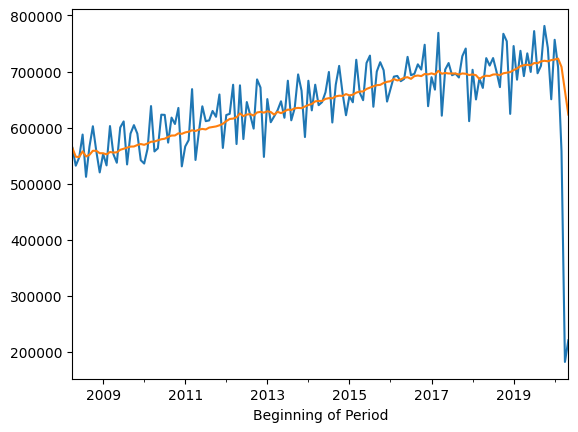

In [5]:
elective_surgeries.plot()
elective_surgeries.rolling(12,min_periods=1).mean().plot()

<AxesSubplot: xlabel='Beginning of Period'>

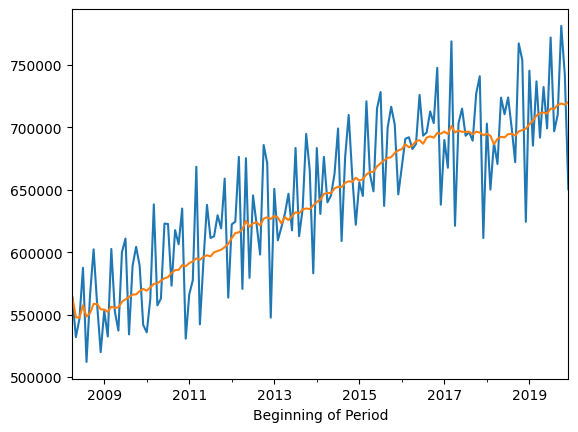

In [6]:
elective_surgeries = elective_surgeries.drop(elective_surgeries.tail(5).index)
elective_surgeries.plot()
elective_surgeries.rolling(12,min_periods=1).mean().plot()

<AxesSubplot: xlabel='Beginning of Period'>

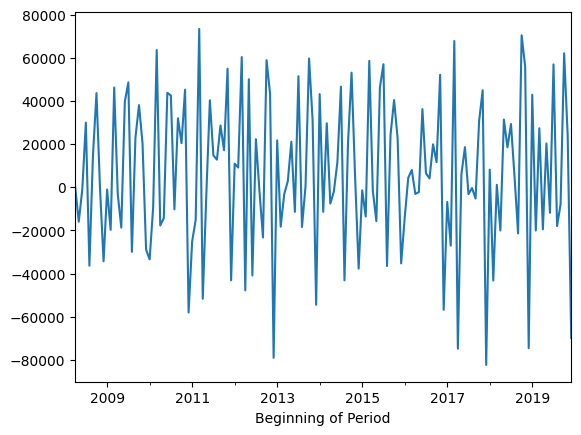

In [7]:
(elective_surgeries - elective_surgeries.rolling(12,min_periods=1).mean()).plot()

In [8]:
elective_less_trend = (elective_surgeries - 
                       elective_surgeries.rolling(12,min_periods=1).mean()).values

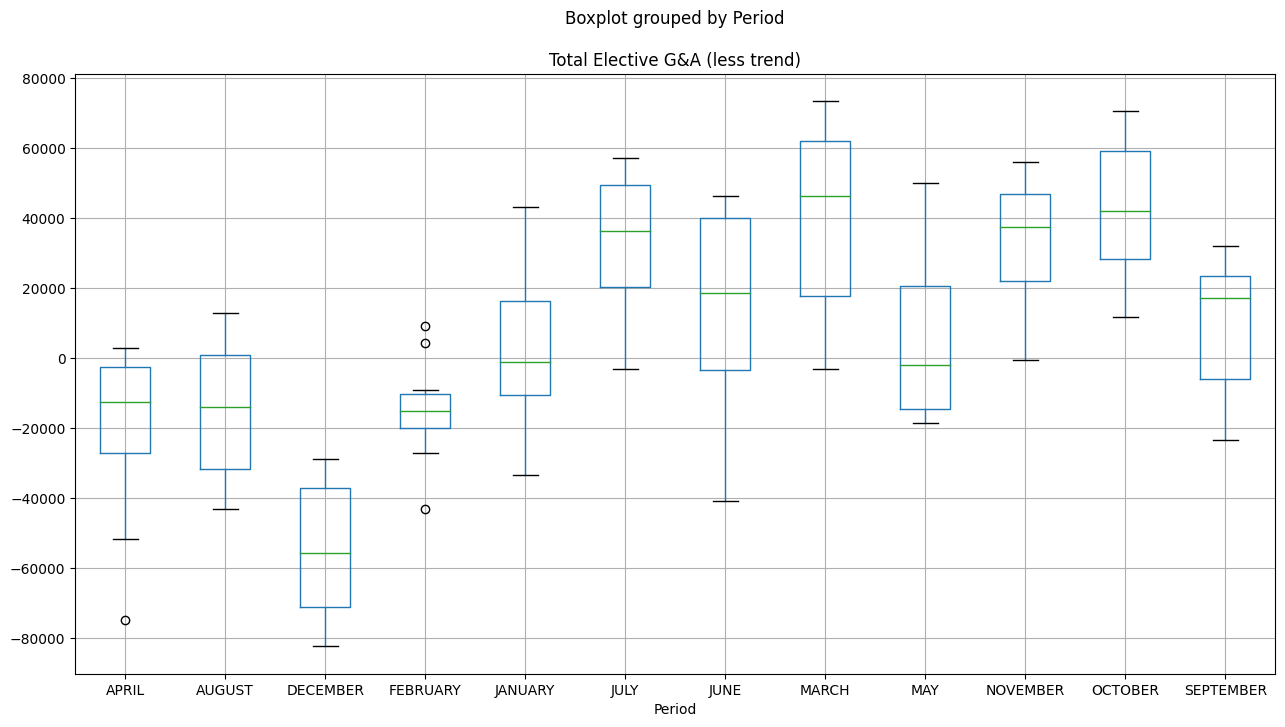

In [9]:
admissions.drop(admissions.tail(5).index, inplace = True)
admissions['Total Elective G&A (less trend)'] = elective_less_trend
admissions.boxplot(column = 'Total Elective G&A (less trend)',by='Period', figsize=(15,8));

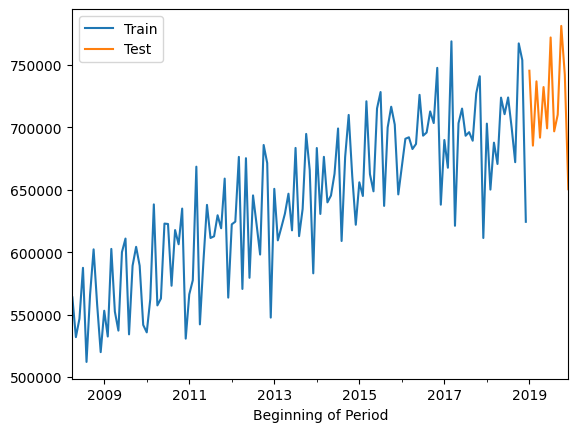

In [10]:
train = elective_surgeries[:'2018']
test = elective_surgeries['2019':]
train.plot()
test.plot()
plt.legend(['Train','Test'])

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           16     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.23682D+01    |proj g|=  9.88789D-01

At iterate    1    f=  1.18534D+01    |proj g|=  6.39652D-01

At iterate    2    f=  1.18275D+01    |proj g|=  1.58866D-01

At iterate    3    f=  1.18179D+01    |proj g|=  1.09604D-01

At iterate    4    f=  1.18122D+01    |proj g|=  1.00800D-01

At iterate    5    f=  1.18109D+01    |proj g|=  5.07050D-02

At iterate    6    f=  1.18095D+01    |proj g|=  2.24258D-02

At iterate    7    f=  1.18092D+01    |proj g|=  2.59268D-02

At iterate    8    f=  1.18090D+01    |proj g|=  9.24700D-03

At iterate    9    f=  1.18090D+01    |proj g|=  1.25482D-03

At iterate   10    f=  1.18090D+01    |proj g|=  6.46594D-05

At iterate   11    f=  1.18090D+01    |proj g|=  1.08359D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function ev

<AxesSubplot: xlabel='Beginning of Period'>

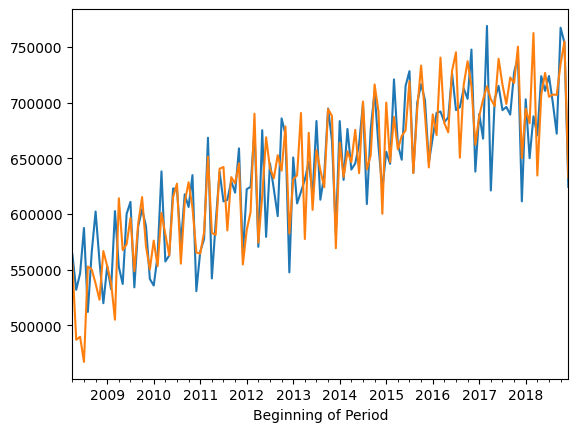

In [11]:
dependent = train.astype('float')

from statsmodels.tsa.exponential_smoothing.ets import ETSModel

etsaa_model = ETSModel(dependent, trend = 'add', seasonal = 'add', seasonal_periods = 12).fit()

dependent.plot()

etsaa_model.fittedvalues.plot()

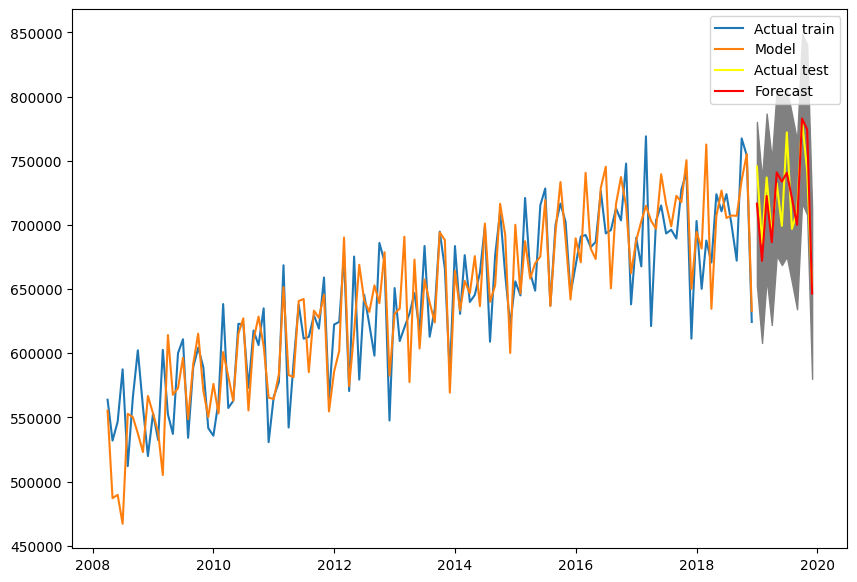

In [12]:
forecast = etsaa_model.get_prediction(start = '2019-01-01', end = '2019-12-01').summary_frame()

plt.figure(figsize=(10,7))
plt.plot(dependent)
plt.plot(etsaa_model.fittedvalues)
plt.plot(test, color='yellow')
plt.plot(forecast['mean'], color='red')
plt.fill_between(
    forecast.index,
    forecast['pi_lower'],
    forecast['pi_upper'], 
    color='grey'
)

plt.legend(['Actual train','Model', 'Actual test','Forecast'])

# Testing forecast

In [14]:
from sklearn.metrics import r2_score

r2_score(test, forecast['mean'])

0.6721184634390189

In [13]:
from sklearn.metrics import mean_absolute_error

mean_absolute_error(test, forecast['mean'])

17349.48073434916

In [14]:
from sklearn.metrics import mean_squared_error

mean_squared_error(test, forecast['mean'])

435777902.74657583

In [15]:
from numpy import sqrt
sqrt(mean_squared_error(test, forecast['mean']))

20875.294075690905

# Building Model on Full Data

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           16     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.23667D+01    |proj g|=  9.88789D-01

At iterate    1    f=  1.18267D+01    |proj g|=  7.37741D-01

At iterate    2    f=  1.18029D+01    |proj g|=  1.65068D-01

At iterate    3    f=  1.17938D+01    |proj g|=  1.18389D-01

At iterate    4    f=  1.17880D+01    |proj g|=  6.54428D-02

At iterate    5    f=  1.17870D+01    |proj g|=  4.81938D-02

At iterate    6    f=  1.17849D+01    |proj g|=  1.25562D-02

At iterate    7    f=  1.17847D+01    |proj g|=  4.12346D-03

At iterate    8    f=  1.17847D+01    |proj g|=  1.33404D-04

At iterate    9    f=  1.17847D+01    |proj g|=  1.86517D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = nu

<AxesSubplot: xlabel='Beginning of Period'>

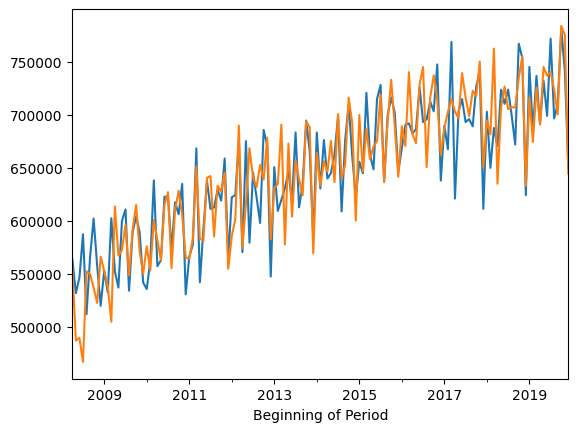

In [16]:
dependent = elective_surgeries.astype('float')

from statsmodels.tsa.exponential_smoothing.ets import ETSModel

ets_full_model = ETSModel(dependent, trend = 'add', seasonal = 'add', seasonal_periods = 12).fit()

dependent.plot() 

ets_full_model.fittedvalues.plot() 

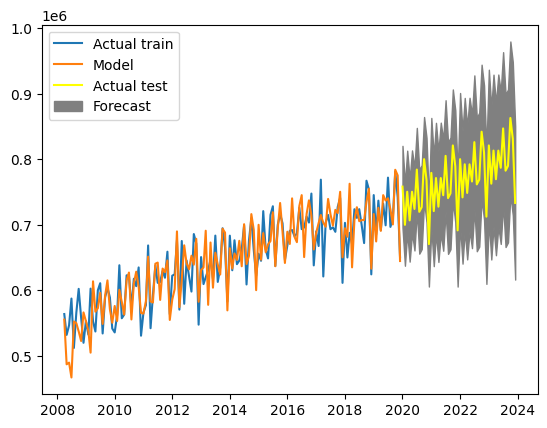

In [17]:
forecast = ets_full_model.get_prediction(start = '2020-01-01', end = '2023-12-01').summary_frame()

plt.plot(dependent)
plt.plot(ets_full_model.fittedvalues)
plt.plot(forecast['mean'], color='yellow')
plt.fill_between(
    forecast.index,
    forecast['pi_lower'],
    forecast['pi_upper'], 
    color='grey'
)
plt.legend(['Actual train','Model', 'Actual test','Forecast'])

# Comparing ETS models

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           16     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.24023D+01    |proj g|=  1.48864D+00

At iterate    1    f=  1.21756D+01    |proj g|=  9.99961D+00

At iterate    2    f=  1.18447D+01    |proj g|=  9.76626D+00

At iterate    3    f=  1.17193D+01    |proj g|=  1.02600D+00

At iterate    4    f=  1.16954D+01    |proj g|=  5.89370D+00

At iterate    5    f=  1.16912D+01    |proj g|=  4.22121D+00

At iterate    6    f=  1.16834D+01    |proj g|=  9.06693D-01

At iterate    7    f=  1.16801D+01    |proj g|=  6.67720D-01

At iterate    8    f=  1.16676D+01    |proj g|=  5.55391D+00

At iterate    9    f=  1.16494D+01    |proj g|=  7.87943D+00

At iterate   10    f=  1.16094D+01    |proj g|=  2.00231D+00

At iterate   11    f=  1.16012D+01    |proj g|=  2.88981D+00

At iterate   12    f=  1.15959D+01    |proj g|=  1.86249D+00

At iterate   13    f=  1.1

<AxesSubplot: xlabel='Beginning of Period'>

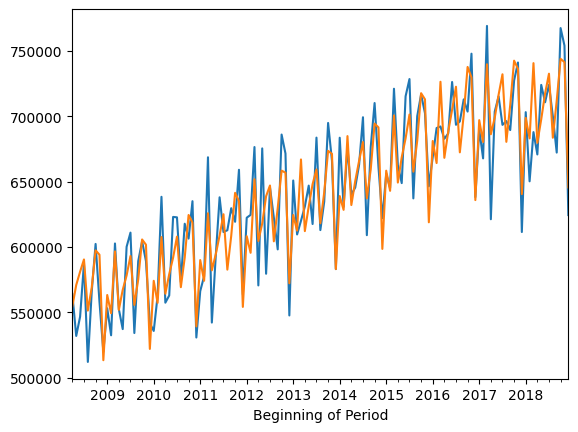

In [18]:
dependent = train.astype('float')

from statsmodels.tsa.exponential_smoothing.ets import ETSModel

etsmm_model = ETSModel(dependent, trend = 'mul', seasonal = 'mul', seasonal_periods = 12).fit()

dependent.plot() # this will plot the actual passengers

etsmm_model.fittedvalues.plot() # this will plot the modelled passengers

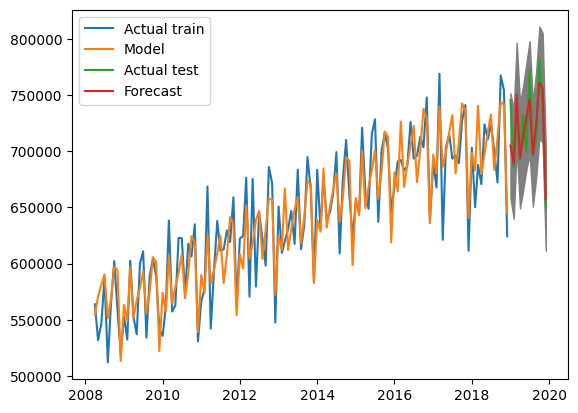

In [19]:
forecast = etsmm_model.get_prediction(start = '2019-01-01', end = '2019-12-01').summary_frame()

plt.plot(dependent)
plt.plot(etsmm_model.fittedvalues)
plt.plot(test)
plt.plot(forecast['mean'])
plt.fill_between(
    forecast.index,
    forecast['pi_lower'],
    forecast['pi_upper'], 
    color='grey'
)
plt.legend(['Actual train','Model', 'Actual test','Forecast'])

In [20]:
dependent = train.astype('float')

# ETS(A,A) model
etsaa_model = ETSModel(dependent, trend = 'add', seasonal = 'add', seasonal_periods = 12).fit()
aa_forecast = etsaa_model.get_prediction(start = '2019-01-01', end = '2019-12-01').summary_frame()
print(r2_score(test, aa_forecast['mean']))

# ETS(M,M) model
etsmm_model = ETSModel(dependent, trend = 'mul', seasonal = 'mul', seasonal_periods = 12).fit()
mm_forecast = etsmm_model.get_prediction(start = '2019-01-01', end = '2019-12-01').summary_frame()
print(r2_score(test, mm_forecast['mean']))

RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           16     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.23682D+01    |proj g|=  9.88789D-01

At iterate    1    f=  1.18534D+01    |proj g|=  6.39652D-01

At iterate    2    f=  1.18275D+01    |proj g|=  1.58866D-01

At iterate    3    f=  1.18179D+01    |proj g|=  1.09604D-01

At iterate    4    f=  1.18122D+01    |proj g|=  1.00800D-01

At iterate    5    f=  1.18109D+01    |proj g|=  5.07050D-02

At iterate    6    f=  1.18095D+01    |proj g|=  2.24258D-02

At iterate    7    f=  1.18092D+01    |proj g|=  2.59268D-02

At iterate    8    f=  1.18090D+01    |proj g|=  9.24700D-03

At iterate    9    f=  1.18090D+01    |proj g|=  1.25482D-03

At iterate   10    f=  1.18090D+01    |proj g|=  6.46594D-05

At iterate   11    f=  1.18090D+01    |proj g|=  1.08359D-05

           * * *

Tit   = total number of iterations
Tnf   = total number of function ev

In [21]:
print(mean_absolute_error(test, aa_forecast['mean']))

17349.48073434916


In [22]:
print(mean_absolute_error(test, mm_forecast['mean']))

15903.33799451997
